In [4]:
import requests
import zipfile
import os

url = "https://github.com/nikostsagk/signature-verification/releases/download/cedar/cedar_dataset.zip"

zip_path = "cedar_dataset.zip"

print("Downloading CEDAR dataset...")

response = requests.get(url)

with open(zip_path, "wb") as f:
    f.write(response.content)

print("Download complete!")

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("CEDAR")

print("Dataset extracted!")

Download complete!
Dataset extracted!


In [5]:
import os

print(os.listdir("CEDAR"))

['full_forg', 'full_org', 'Readme.txt', '__MACOSX']


In [6]:
import glob

genuine = glob.glob("CEDAR/full_org/*")
forged = glob.glob("CEDAR/full_forg/*")

print("Genuine signatures:", len(genuine))
print("Forged signatures:", len(forged))

Genuine signatures: 1321
Forged signatures: 1321


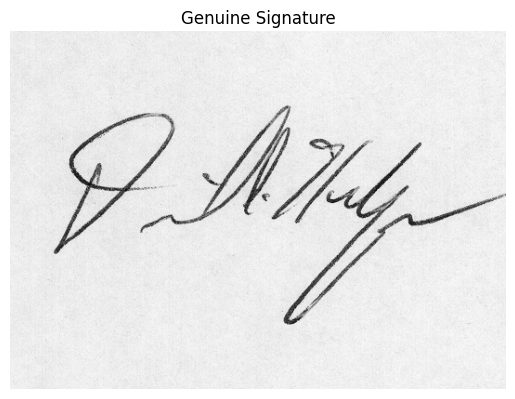

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(genuine[0])

plt.imshow(img, cmap="gray")
plt.title("Genuine Signature")
plt.axis("off")
plt.show()

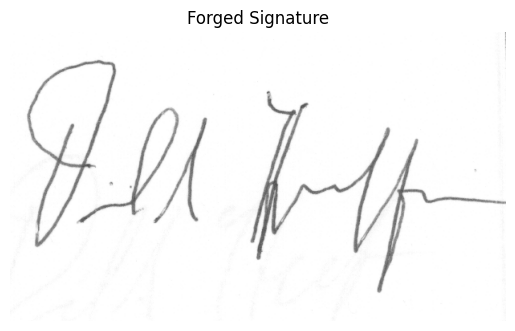

In [8]:
img = Image.open(forged[0])

plt.imshow(img, cmap="gray")
plt.title("Forged Signature")
plt.axis("off")
plt.show()

In [9]:
print("Genuine image size:", Image.open(genuine[0]).size)
print("Forged image size:", Image.open(forged[0]).size)

Genuine image size: (534, 385)
Forged image size: (618, 360)


In [10]:
import numpy as np
from PIL import Image

In [11]:
IMG_WIDTH = 128
IMG_HEIGHT = 64

In [12]:
def preprocess_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    
    img = np.array(img)
    img = img / 255.0
    
    return img

In [13]:
test_image = preprocess_image(genuine[0])

print("Image shape:", test_image.shape)
print("Minimum pixel value:", test_image.min())
print("Maximum pixel value:", test_image.max())

Image shape: (64, 128)
Minimum pixel value: 0.41568627450980394
Maximum pixel value: 0.9647058823529412


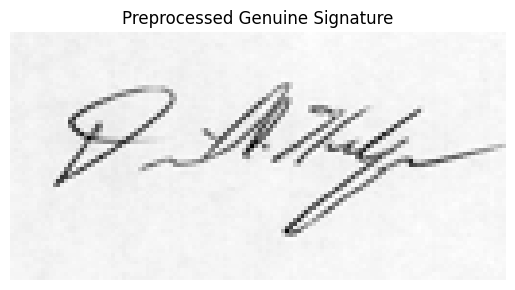

In [14]:
plt.imshow(test_image, cmap="gray")
plt.title("Preprocessed Genuine Signature")
plt.axis("off")
plt.show()

In [18]:
X = []
y = []

for path in genuine:
    if path.lower().endswith((".png", ".jpg", ".jpeg")):
        X.append(preprocess_image(path))
        y.append(0)

for path in forged:
    if path.lower().endswith((".png", ".jpg", ".jpeg")):
        X.append(preprocess_image(path))
        y.append(1)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2640, 64, 128)
y shape: (2640,)


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])

print("Training labels:", y_train.shape[0])
print("Testing labels:", y_test.shape[0])

Training images: 2112
Testing images: 528
Training labels: 2112
Testing labels: 528


In [22]:
print("Training - Genuine:", np.sum(y_train == 0))
print("Training - Forged:", np.sum(y_train == 1))

print("Testing - Genuine:", np.sum(y_test == 0))
print("Testing - Forged:", np.sum(y_test == 1))

Training - Genuine: 1056
Training - Forged: 1056
Testing - Genuine: 264
Testing - Forged: 264


In [23]:
X_train = X_train.reshape(-1, 64, 128, 1)
X_test = X_test.reshape(-1, 64, 128, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2112, 64, 128, 1)
X_test shape: (528, 64, 128, 1)


In [24]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [25]:
model = Sequential([
    
    Conv2D(32, (3, 3), activation="relu", input_shape=(64, 128, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 126, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,376,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,469,185 (5.60 MB)

 Trainable params: 1,469,185 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
print("CNN model created and compiled successfully!")

CNN model created and compiled successfully!


In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.5056 - loss: 0.7025 - val_accuracy: 0.4634 - val_loss: 0.6957
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 318ms/step - accuracy: 0.5287 - loss: 0.6921 - val_accuracy: 0.4634 - val_loss: 0.6965
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.5417 - loss: 0.6878 - val_accuracy: 0.6265 - val_loss: 0.6729
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 284ms/step - accuracy: 0.6098 - loss: 0.6584 - val_accuracy: 0.6288 - val_loss: 0.6422
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.6572 - loss: 0.6253 - val_accuracy: 0.6927 - val_loss: 0.5974
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.6963 - loss: 0.5862 - val_accuracy: 0.6950 - val_loss: 0.5764
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.7401 - loss: 0.5352 - val_accuracy: 0.7376 - val_loss: 0.5197
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.7863 - loss: 0.4712 - val_accu

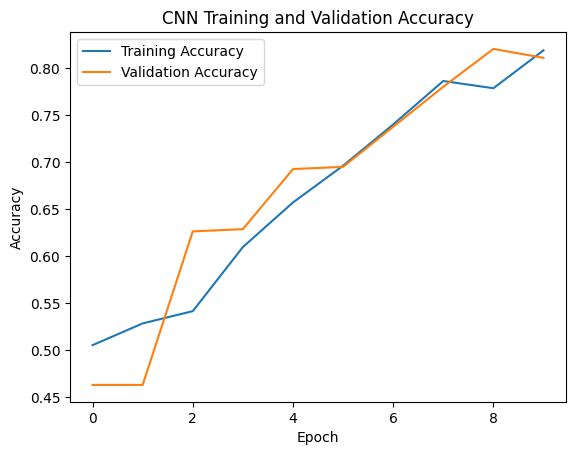

In [30]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

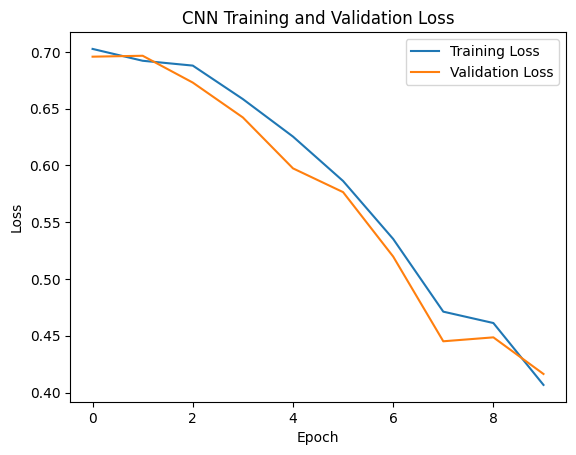

In [31]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [32]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.8314 - loss: 0.3634
Test Accuracy: 0.8314393758773804
Test Loss: 0.36342865228652954


In [33]:
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Test Accuracy: 83.14%


In [34]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

print("Predictions generated!")

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step
Predictions generated!


In [35]:
for i in range(10):
    actual = "Genuine" if y_test[i] == 0 else "Forged"
    predicted = "Genuine" if y_pred[i] == 0 else "Forged"

    print(
        f"Image {i+1}: Actual = {actual}, "
        f"Predicted = {predicted}"
    )

Image 1: Actual = Forged, Predicted = Forged
Image 2: Actual = Genuine, Predicted = Forged
Image 3: Actual = Forged, Predicted = Forged
Image 4: Actual = Forged, Predicted = Forged
Image 5: Actual = Genuine, Predicted = Genuine
Image 6: Actual = Forged, Predicted = Forged
Image 7: Actual = Genuine, Predicted = Genuine
Image 8: Actual = Genuine, Predicted = Genuine
Image 9: Actual = Forged, Predicted = Forged
Image 10: Actual = Forged, Predicted = Forged


In [36]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

In [37]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[209  55]
 [ 34 230]]


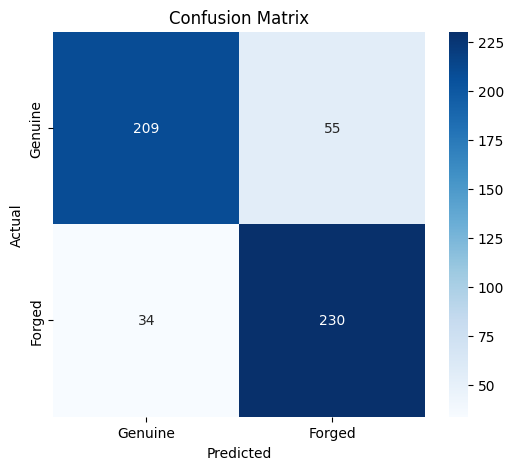

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Forged"],
    yticklabels=["Genuine", "Forged"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Forged"]
)

print(report)

              precision    recall  f1-score   support

     Genuine       0.86      0.79      0.82       264
      Forged       0.81      0.87      0.84       264

    accuracy                           0.83       528
   macro avg       0.83      0.83      0.83       528
weighted avg       0.83      0.83      0.83       528



In [40]:
print("===== SIGNATURE FORGERY DETECTION RESULTS =====")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print()
print(report)

===== SIGNATURE FORGERY DETECTION RESULTS =====
Test Accuracy: 83.14%

              precision    recall  f1-score   support

     Genuine       0.86      0.79      0.82       264
      Forged       0.81      0.87      0.84       264

    accuracy                           0.83       528
   macro avg       0.83      0.83      0.83       528
weighted avg       0.83      0.83      0.83       528



In [41]:
index = 0

image = X_test[index]
actual_label = y_test[index]

print("Actual label:", actual_label)

Actual label: 1


In [42]:
prediction = model.predict(image.reshape(1, 64, 128, 1))[0][0]

print("Prediction probability:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
Prediction probability: 0.8288498


In [43]:
predicted_label = 1 if prediction >= 0.5 else 0

actual = "Forged" if actual_label == 1 else "Genuine"
predicted = "Forged" if predicted_label == 1 else "Genuine"

print("Actual:", actual)
print("Predicted:", predicted)

Actual: Forged
Predicted: Forged


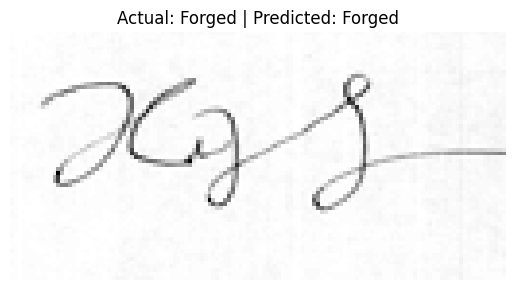

In [44]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual: {actual} | Predicted: {predicted}")
plt.axis("off")
plt.show()